In [9]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score
print("Libraries successfully imported")

Libraries successfully imported


In [8]:
ticker='AAPL'
stock_data=yf.download(ticker,start='2024-01-01',end='2026-06-01')
print(f"{ticker} Stock Data Head")
print(stock_data.head())

print("\n Data Summary")
print(stock_data.info())

[*********************100%***********************]  1 of 1 completed

AAPL Stock Data Head
Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  183.562210  186.330874  181.831797  185.055304  82488700
2024-01-03  182.187729  183.799489  181.376900  182.158066  58414500
2024-01-04  179.873932  181.040717  178.855462  180.111236  71983600
2024-01-05  179.152115  180.714432  178.153425  179.953062  62379700
2024-01-08  183.483063  183.522623  179.468508  180.051901  59144500

 Data Summary
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 604 entries, 2024-01-02 to 2026-05-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   604 non-null    float64
 1   (High, AAPL)    604 non-null    float64
 2   (Low, AAPL)     604 non-null    float64
 3   (Open, AAPL)    604 non-null    float64
 4   (Volume, AAPL)

In [12]:
X=stock_data[['Open','High','Low','Volume']]
y=stock_data['Close']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=False)
print(f"Training data size:{X_train.shape}")
print(f"Testing data size:{X_test.shape}")

Training data size:(483, 4)
Testing data size:(121, 4)


In [13]:
model=LinearRegression()
model.fit(X_train,y_train)
predictions=model.predict(X_test)
mae=mean_absolute_error(y_test,predictions)
r2=r2_score(y_test,predictions)
print(f"Mean Absolute Error (MAE):{mae:.2f}")
print(f"R-squared (R2) Score:{r2:.2f}")

Mean Absolute Error (MAE):1.11
R-squared (R2) Score:0.99


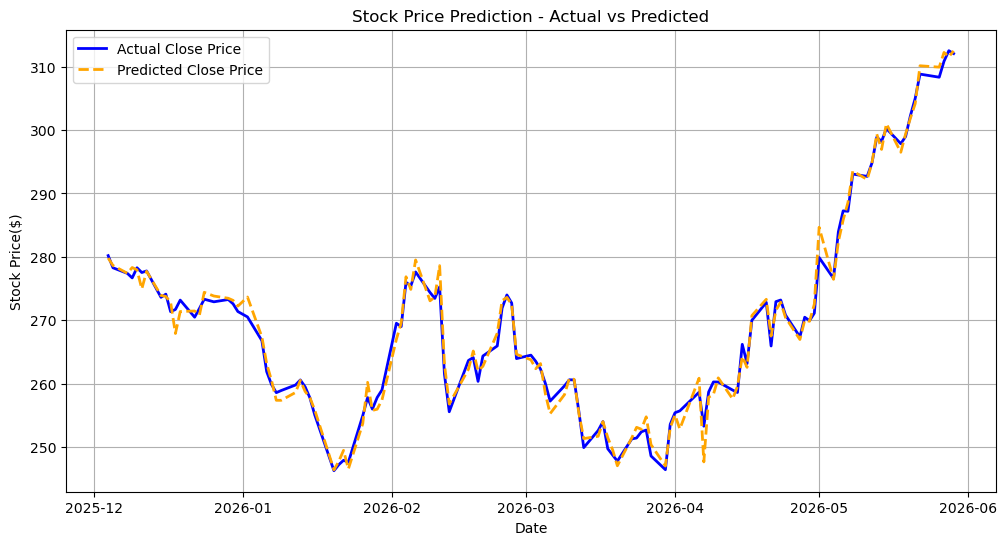

In [15]:
plt.figure(figsize=(12,6))
plt.plot(y_test.index,y_test.values,label='Actual Close Price',color='blue',linewidth=2)
plt.plot(y_test.index,predictions,label='Predicted Close Price',color='orange',linestyle='--',linewidth=2)
plt.title(f"Stock Price Prediction - Actual vs Predicted")
plt.xlabel('Date')
plt.ylabel('Stock Price($)')
plt.legend()
plt.grid(True)
plt.show()